# Biomarker Comparison: Cognitive Stress vs Physical Stress

**Goal**: Determine if we can distinguish **cognitive stress** from **physical stress** (aerobic/anaerobic exercise) using wearable biosignals.

**Key Question**: *Can we really distinguish cognitive stress apart from aerobic/anaerobic?*

### WHY it matters
- All three conditions (cognitive stress, aerobic, anaerobic) elevate HR and movement
- If biomarkers overlap significantly, a stress classifier trained on lab data may misclassify exercise as stress

#### STEPS
1. Load preprocessed data from `preprocess_wise.py` (sliding windows + per-subject imputation)
2. Statistical comparison (ANOVA + post-hoc tests)
3. Visualization of feature distributions
4. Build a 3-class Activity Classifier
5. Apple Watch feature-only model

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from scipy import stats
from scipy.stats import f_oneway, ttest_ind
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import cross_val_score, cross_validate, LeaveOneGroupOut, train_test_split, GroupShuffleSplit
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix

# ── Load ALL preprocessed data from shared pipeline ──
from preprocess_wise import (df_activity, ALL_FEATURES, APPLE_WATCH_FEATURES,
                               WINDOW_SIZE_SEC, WINDOW_OVERLAP)

# Use df_activity for this notebook (COGNITIVE + AEROBIC + ANAEROBIC)
df_combined = df_activity.copy()

# Rename 'subject' to 'subject_id' for this notebook's LOSO code
df_combined['subject_id'] = df_combined['subject']

print("COMBINED DATASET SUMMARY (from preprocess_wise.py)")
print(f"{'='*60}")
print(f"Total windows: {len(df_combined)}")
print(f"Window config: {WINDOW_SIZE_SEC}s, {WINDOW_OVERLAP*100:.0f}% overlap")
print(f"\nBy Activity Type:")
print(df_combined['activity_type'].value_counts())
print(f"\nUnique subjects: {df_combined['subject_id'].nunique()}")
print(f"\nPreprocessing: sliding windows + per-subject HRV imputation")
print(f"Features: {ALL_FEATURES}")

COMBINED DATASET SUMMARY (from preprocess_wise.py)
Total windows: 2449
Window config: 30s, 50% overlap

By Activity Type:
activity_type
AEROBIC      1968
COGNITIVE     413
ANAEROBIC      68
Name: count, dtype: int64

Unique subjects: 22

Preprocessing: sliding windows + per-subject HRV imputation
Features: ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 'HR_max', 'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']


---
## 3. Statistical Comparison: ANOVA + Post-hoc Tests

**Key Question**: Which biomarkers significantly differ across the three activity types?

In [2]:
# Define features to compare
biomarkers = ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 
              'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']

# Filter to only include features that exist
biomarkers = [b for b in biomarkers if b in df_combined.columns]

print(f"{'='*80}")
print("ANOVA: Comparing Biomarkers Across COGNITIVE vs AEROBIC vs ANAEROBIC")
print(f"{'='*80}")
print(f"{'Biomarker':<12} {'F-stat':<10} {'p-value':<12} {'Sig':<5} {'COGNITIVE':<12} {'AEROBIC':<12} {'ANAEROBIC':<12}")
print("-" * 80)

anova_results = []

for bio in biomarkers:
    cognitive = df_combined[df_combined['activity_type'] == 'COGNITIVE'][bio].dropna()
    aerobic = df_combined[df_combined['activity_type'] == 'AEROBIC'][bio].dropna()
    anaerobic = df_combined[df_combined['activity_type'] == 'ANAEROBIC'][bio].dropna()
    
    if len(cognitive) > 2 and len(aerobic) > 2 and len(anaerobic) > 2:
        # One-way ANOVA
        f_stat, p_val = f_oneway(cognitive, aerobic, anaerobic)
        
        
        # Significance
        if p_val < 0.001:
            sig = "***"
        elif p_val < 0.01:
            sig = "**"
        elif p_val < 0.05:
            sig = "*"
        else:
            sig = "ns"
        
        print(f"{bio:<12} {f_stat:<10.2f} {p_val:<12.6f} {sig:<5} {cognitive.mean():<12.2f} {aerobic.mean():<12.2f} {anaerobic.mean():<12.2f}")
        
        anova_results.append({
            'biomarker': bio,
            'f_stat': f_stat,
            'p_value': p_val,
            'significant': sig != 'ns',
            'cognitive_mean': cognitive.mean(),
            'aerobic_mean': aerobic.mean(),
            'anaerobic_mean': anaerobic.mean()
        })

print("\n* p<0.05  ** p<0.01  *** p<0.001  ns = not significant")

df_anova = pd.DataFrame(anova_results)

ANOVA: Comparing Biomarkers Across COGNITIVE vs AEROBIC vs ANAEROBIC
Biomarker    F-stat     p-value      Sig   COGNITIVE    AEROBIC      ANAEROBIC   
--------------------------------------------------------------------------------
SDNN         3.35       0.035191     *     0.05         0.04         0.04        
RMSSD        15.74      0.000000     ***   0.05         0.06         0.06        
EDA_mean     8.60       0.000190     ***   5.06         7.33         7.70        
EDA_std      35.54      0.000000     ***   0.19         0.36         0.88        
HR_mean      71.96      0.000000     ***   82.41        99.16        99.92       
HR_std       40.28      0.000000     ***   1.11         1.26         2.76        
TEMP_mean    22.90      0.000000     ***   32.55        31.82        37.58       
TEMP_std     0.54       0.580444     ns    0.02         0.15         0.12        
ACC_mean     825.95     0.000000     ***   0.91         3.73         10.24       
ACC_std      632.93     0.0000

In [4]:
# Post-hoc pairwise comparisons (for significant features)
from scipy.stats import ttest_ind

print(f"\n{'='*80}")
print("POST-HOC PAIRWISE COMPARISONS (Welch's t-test)")
print(f"{'='*80}")

significant_biomarkers = df_anova[df_anova['significant']]['biomarker'].tolist()

for bio in significant_biomarkers:
    cognitive = df_combined[df_combined['activity_type'] == 'COGNITIVE'][bio].dropna()
    aerobic = df_combined[df_combined['activity_type'] == 'AEROBIC'][bio].dropna()
    anaerobic = df_combined[df_combined['activity_type'] == 'ANAEROBIC'][bio].dropna()
    
    print(f"\n{bio}:")
    
    # Cognitive vs Aerobic
    t1, p1 = ttest_ind(cognitive, aerobic, equal_var=False)
    sig1 = "***" if p1 < 0.001 else "**" if p1 < 0.01 else "*" if p1 < 0.05 else "ns"
    print(f"  COGNITIVE vs AEROBIC:   p={p1:.6f} {sig1}")
    
    # Cognitive vs Anaerobic
    t2, p2 = ttest_ind(cognitive, anaerobic, equal_var=False)
    sig2 = "***" if p2 < 0.001 else "**" if p2 < 0.01 else "*" if p2 < 0.05 else "ns"
    print(f"  COGNITIVE vs ANAEROBIC: p={p2:.6f} {sig2}")
    
    # Aerobic vs Anaerobic
    t3, p3 = ttest_ind(aerobic, anaerobic, equal_var=False)
    sig3 = "***" if p3 < 0.001 else "**" if p3 < 0.01 else "*" if p3 < 0.05 else "ns"
    print(f"  AEROBIC vs ANAEROBIC:   p={p3:.6f} {sig3}")


POST-HOC PAIRWISE COMPARISONS (Welch's t-test)

SDNN:
  COGNITIVE vs AEROBIC:   p=0.000003 ***
  COGNITIVE vs ANAEROBIC: p=0.406220 ns
  AEROBIC vs ANAEROBIC:   p=0.313535 ns

RMSSD:
  COGNITIVE vs AEROBIC:   p=0.000000 ***
  COGNITIVE vs ANAEROBIC: p=0.000025 ***
  AEROBIC vs ANAEROBIC:   p=0.468550 ns

EDA_mean:
  COGNITIVE vs AEROBIC:   p=0.000000 ***
  COGNITIVE vs ANAEROBIC: p=0.034607 *
  AEROBIC vs ANAEROBIC:   p=0.714036 ns

EDA_std:
  COGNITIVE vs AEROBIC:   p=0.000000 ***
  COGNITIVE vs ANAEROBIC: p=0.000005 ***
  AEROBIC vs ANAEROBIC:   p=0.000833 ***

HR_mean:
  COGNITIVE vs AEROBIC:   p=0.000000 ***
  COGNITIVE vs ANAEROBIC: p=0.000000 ***
  AEROBIC vs ANAEROBIC:   p=0.768665 ns

HR_std:
  COGNITIVE vs AEROBIC:   p=0.000000 ***
  COGNITIVE vs ANAEROBIC: p=0.000000 ***
  AEROBIC vs ANAEROBIC:   p=0.000000 ***

TEMP_mean:
  COGNITIVE vs AEROBIC:   p=0.000000 ***
  COGNITIVE vs ANAEROBIC: p=0.093965 ns
  AEROBIC vs ANAEROBIC:   p=0.058738 ns

ACC_mean:
  COGNITIVE vs AEROBIC

---
## 4. Visualizations

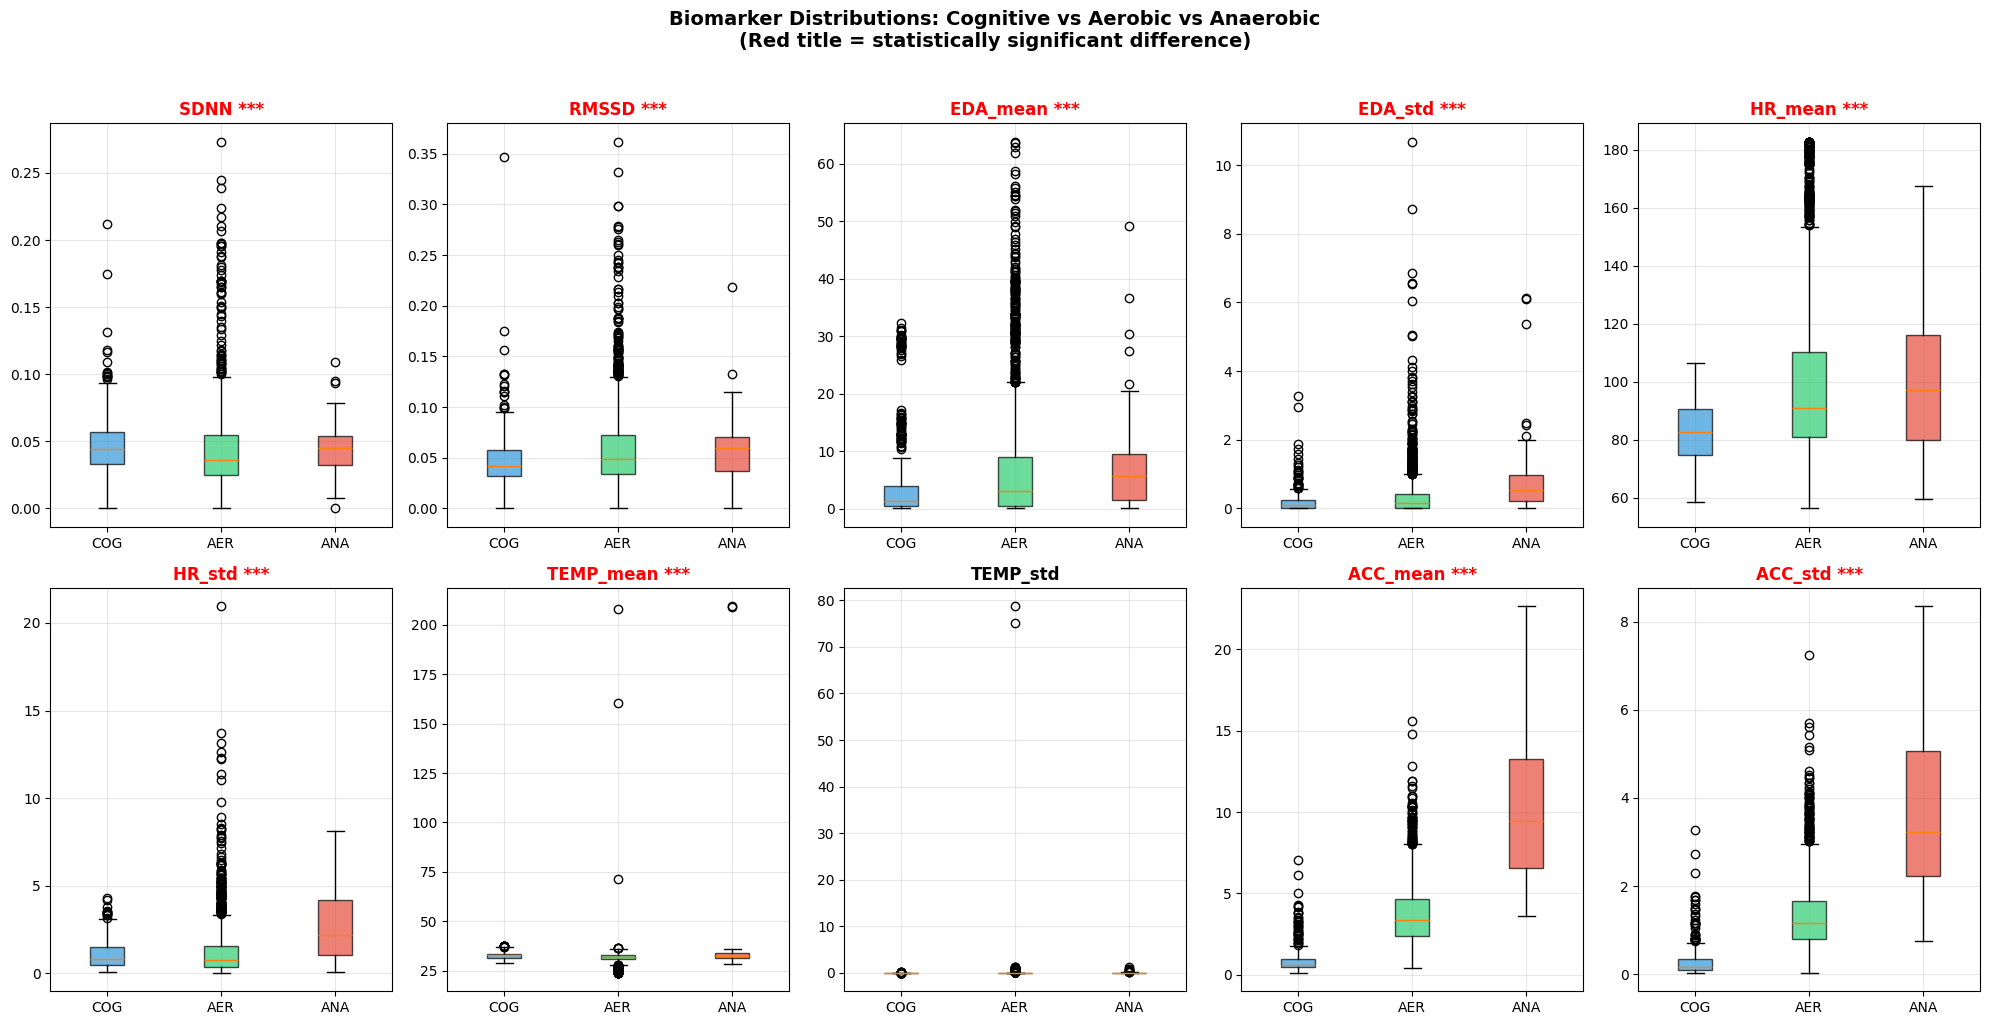

In [17]:
# Box plots comparing distributions
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

colors = {'COGNITIVE': '#3498db', 'AEROBIC': '#2ecc71', 'ANAEROBIC': '#e74c3c'}

for i, bio in enumerate(biomarkers):
    ax = axes[i]
    
    # Create box plot data
    data_to_plot = []
    labels = []
    for activity in ['COGNITIVE', 'AEROBIC', 'ANAEROBIC']:
        vals = df_combined[df_combined['activity_type'] == activity][bio].dropna()
        data_to_plot.append(vals)
        labels.append(activity)
    
    bp = ax.boxplot(data_to_plot, labels=['COG', 'AER', 'ANA'], patch_artist=True)
    
    for patch, color in zip(bp['boxes'], [colors['COGNITIVE'], colors['AEROBIC'], colors['ANAEROBIC']]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title(bio, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add significance marker if ANOVA was significant
    if bio in significant_biomarkers:
        ax.set_title(f"{bio} ***", fontsize=12, fontweight='bold', color='red')

# Hide empty subplots
for j in range(len(biomarkers), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Biomarker Distributions: Cognitive vs Aerobic vs Anaerobic\n(Red title = statistically significant difference)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

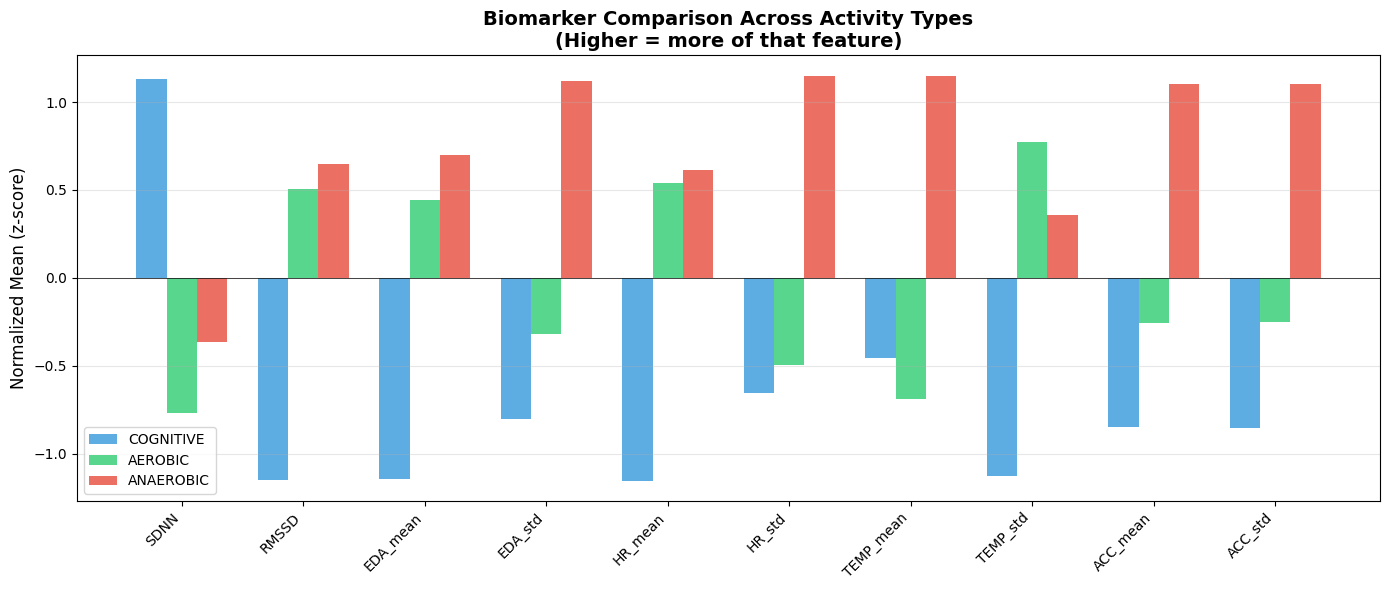

In [18]:
# Mean comparison bar chart
fig, ax = plt.subplots(figsize=(14, 6))

# Normalize means for visualization (z-score across activities)
means_df = df_combined.groupby('activity_type')[biomarkers].mean()
means_normalized = (means_df - means_df.mean()) / means_df.std()

x = np.arange(len(biomarkers))
width = 0.25

bars1 = ax.bar(x - width, means_normalized.loc['COGNITIVE'], width, label='COGNITIVE', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, means_normalized.loc['AEROBIC'], width, label='AEROBIC', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + width, means_normalized.loc['ANAEROBIC'], width, label='ANAEROBIC', color='#e74c3c', alpha=0.8)

ax.set_ylabel('Normalized Mean (z-score)', fontsize=12)
ax.set_title('Biomarker Comparison Across Activity Types\n(Higher = more of that feature)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(biomarkers, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

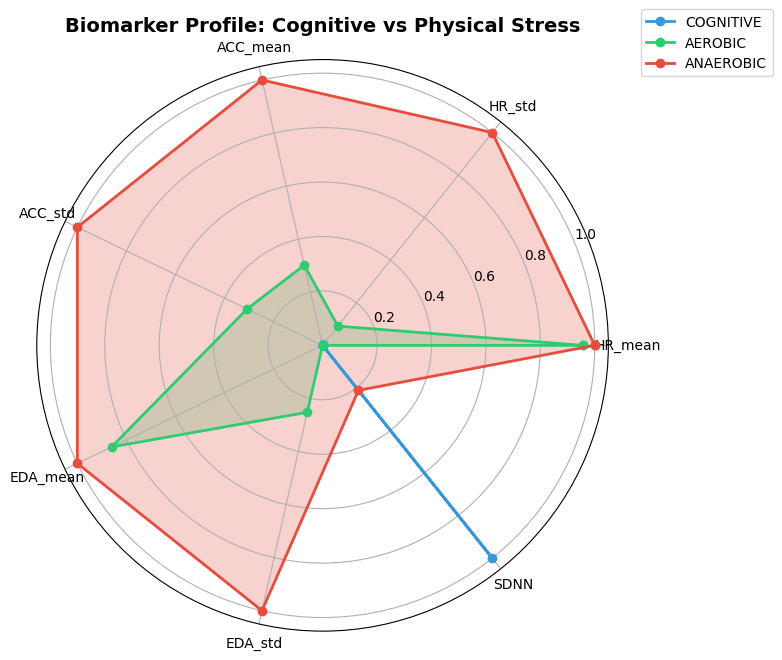

In [19]:
# Radar/Spider chart for each activity type
from math import pi

# Select key biomarkers for radar chart
radar_features = ['HR_mean', 'HR_std', 'ACC_mean', 'ACC_std', 'EDA_mean', 'EDA_std', 'SDNN']
radar_features = [f for f in radar_features if f in df_combined.columns]

# Normalize to 0-1 scale for radar
means = df_combined.groupby('activity_type')[radar_features].mean()
means_norm = (means - means.min()) / (means.max() - means.min())

# Number of variables
N = len(radar_features)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # complete the loop

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = {'COGNITIVE': '#3498db', 'AEROBIC': '#2ecc71', 'ANAEROBIC': '#e74c3c'}

for activity in ['COGNITIVE', 'AEROBIC', 'ANAEROBIC']:
    values = means_norm.loc[activity].values.tolist()
    values += values[:1]  # complete the loop
    
    ax.plot(angles, values, 'o-', linewidth=2, label=activity, color=colors[activity])
    ax.fill(angles, values, alpha=0.25, color=colors[activity])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=10)
ax.set_title('Biomarker Profile: Cognitive vs Physical Stress', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

---
## 4.5 Per-Subject Imputation (Lev's Note)

**Already applied in `preprocess_wise.py`** — 829 missing SDNN/RMSSD values filled with each subject's own mean (falls back to global mean if all NaN).

This preserves individual HRV variance vs global mean imputation which compresses it.

---
## 5. Start to build a 3-Class Activity Classifier

**Goal**: Can we classify segments into COGNITIVE, AEROBIC, or ANAEROBIC based on biomarkers alone?

In [3]:
#classification for activity type based on biomarkers
feature_cols = [c for c in biomarkers if c in df_combined.columns]

X = df_combined[feature_cols]
y = df_combined['activity_type']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Features used: {feature_cols}")
print(f"Classes: {le.classes_}")
print(f"Class distribution: {dict(zip(le.classes_, np.bincount(y_encoded)))}")

Features used: ['SDNN', 'RMSSD', 'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 'TEMP_mean', 'TEMP_std', 'ACC_mean', 'ACC_std']
Classes: ['AEROBIC' 'ANAEROBIC' 'COGNITIVE']
Class distribution: {'AEROBIC': 1968, 'ANAEROBIC': 68, 'COGNITIVE': 413}


In [10]:
# 3-CLASS ACTIVITY CLASSIFIER WITH LOSO VALIDATION (Essie's Note)

# Using Leave-One-Subject-Out (LOSO) cross-validation instead of random CV
# This gives realistic accuracy for new users (no data leakage between subjects)

from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC

# Get subject IDs for LOSO
subjects = df_combined['subject_id'].values

classifiers = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', random_state=42)
}

print("3-CLASS ACTIVITY CLASSIFIER COMPARISON")
print(f"Task: Classify COGNITIVE vs AEROBIC vs ANAEROBIC")
print(f"Validation: LOSO (Leave-One-Subject-Out) - realistic accuracy for new users")
print(f"{'='*70}\n")

# Use LOSO cross-validation
logo = LeaveOneGroupOut()
print(f"Number of subjects (folds): {logo.get_n_splits(X, y_encoded, subjects)}")
print()

results = []
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro'
}

for clf_name, clf in classifiers.items():
    pipeline = make_pipeline(
        StandardScaler(),  # No SimpleImputer needed - we did per-subject imputation already
        clf
    )
    
    # LOSO cross-validation
    cv_scores = cross_validate(pipeline, X, y_encoded, cv=logo, groups=subjects, scoring=scoring)
    
    print(
        f"{clf_name:20}: {cv_scores['test_accuracy'].mean():.3f} (+/- {cv_scores['test_accuracy'].std()*2:.3f}) "
        f"F1_macro={cv_scores['test_f1_macro'].mean():.3f}"
         )
    
    results.append({
        'Classifier': clf_name,
        'CV Accuracy': cv_scores['test_accuracy'].mean(),
        'CV STD': cv_scores['test_accuracy'].std(),
        'CV F1_macro': cv_scores['test_f1_macro'].mean(),
        'CV Method': 'LOSO'
    })

df_results = pd.DataFrame(results)
best = df_results.loc[df_results['CV Accuracy'].idxmax()]
print(f"\nBEST: {best['Classifier']} with {best['CV Accuracy']:.1%} LOSO accuracy")

3-CLASS ACTIVITY CLASSIFIER COMPARISON
Task: Classify COGNITIVE vs AEROBIC vs ANAEROBIC
Validation: LOSO (Leave-One-Subject-Out) - realistic accuracy for new users

Number of subjects (folds): 22

Random Forest       : 0.913 (+/- 0.132) F1_macro=0.713
Gradient Boosting   : 0.908 (+/- 0.140) F1_macro=0.748
AdaBoost            : 0.853 (+/- 0.221) F1_macro=0.677
SVM (RBF)           : 0.907 (+/- 0.138) F1_macro=0.675

BEST: Random Forest with 91.3% LOSO accuracy


Note: LOSO accuracy is typically LOWER than random CV but more realistic 
This represents expected performance on a completely new user

Classification Report:

              precision    recall  f1-score   support

     AEROBIC       0.95      0.93      0.94       445
   ANAEROBIC       0.24      0.64      0.35        14
   COGNITIVE       0.96      0.81      0.88        89

    accuracy                           0.90       548
   macro avg       0.72      0.79      0.72       548
weighted avg       0.93      0.90      0.91       548



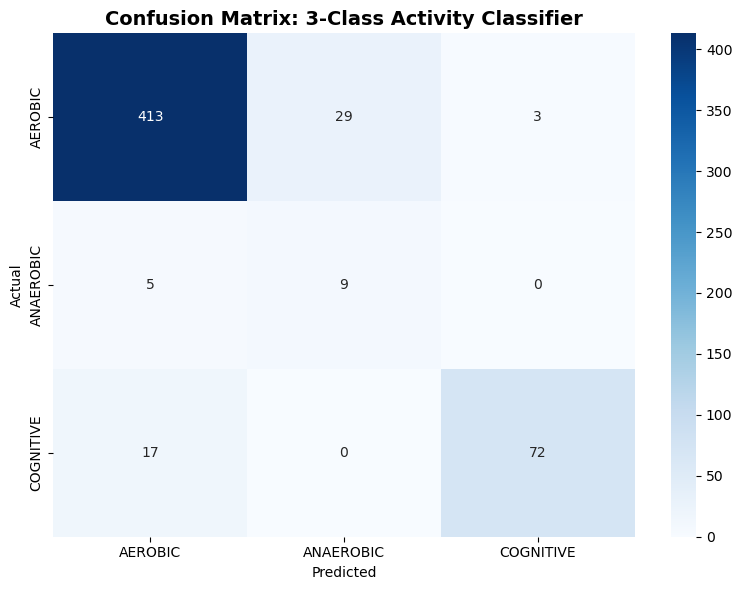

In [7]:
# Train best model and show confusion matrix
from sklearn.model_selection import train_test_split

# Use Random Forest
best_pipeline = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42)
)

# Train/test split
# X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Subject-wise train/test split 
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_encoded, groups=subjects))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

# Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: 3-Class Activity Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

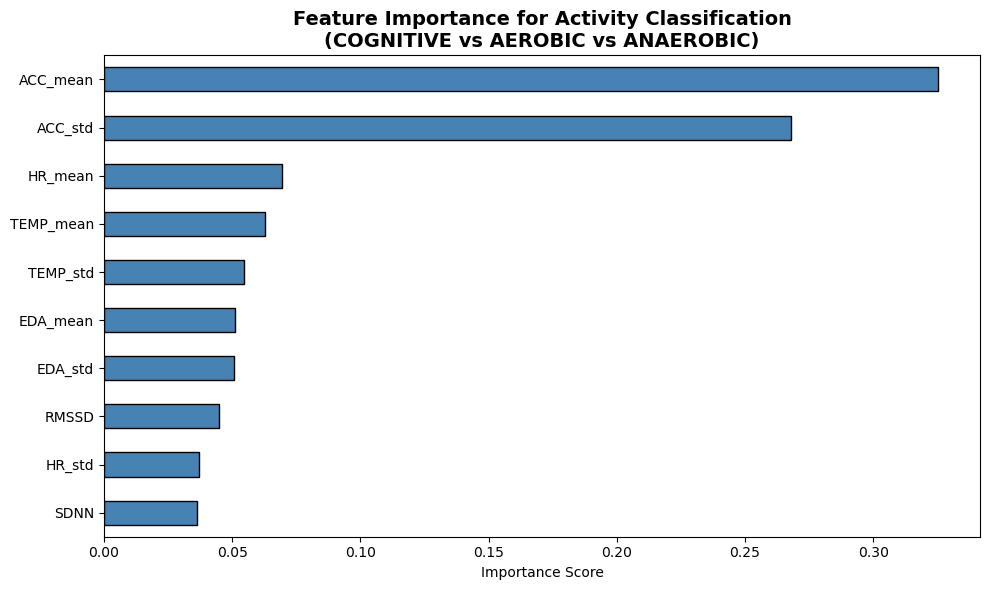


Top 5 Most Important Features for Activity Classification:
  ACC_mean: 0.325
  ACC_std: 0.268
  HR_mean: 0.069
  TEMP_mean: 0.063
  TEMP_std: 0.054


In [8]:
# Feature importance for activity classification
rf_model = best_pipeline.named_steps['randomforestclassifier']
importances = pd.Series(rf_model.feature_importances_, index=feature_cols)

plt.figure(figsize=(10, 6))
importances.sort_values().plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance for Activity Classification\n(COGNITIVE vs AEROBIC vs ANAEROBIC)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features for Activity Classification:")
for feat, imp in importances.sort_values(ascending=False).head(5).items():
    print(f"  {feat}: {imp:.3f}")

---
## 6. Summary of findings

In [9]:
print("BIOMARKER COMPARISON SUMMARY")
print("="*70)

print("\n1. STATISTICALLY SIGNIFICANT DIFFERENCES (ANOVA p < 0.05):")
for _, row in df_anova[df_anova['significant']].iterrows():
    print(f"   - {row['biomarker']}: F={row['f_stat']:.2f}, p={row['p_value']:.6f}")

print("\n2. KEY DISTINGUISHING FEATURES:")
print("   Features that best separate COGNITIVE from PHYSICAL stress:")
for feat, imp in importances.sort_values(ascending=False).head(3).items():
    print(f"   - {feat} (importance: {imp:.3f})")

print(f"\n3. ACTIVITY CLASSIFIER PERFORMANCE:")
print(f"   Best model: {best['Classifier']}")
print(f"   Accuracy: {best['CV Accuracy']:.1%}")

BIOMARKER COMPARISON SUMMARY

1. STATISTICALLY SIGNIFICANT DIFFERENCES (ANOVA p < 0.05):
   - SDNN: F=3.35, p=0.035191
   - RMSSD: F=15.74, p=0.000000
   - EDA_mean: F=8.60, p=0.000190
   - EDA_std: F=35.54, p=0.000000
   - HR_mean: F=71.96, p=0.000000
   - HR_std: F=40.28, p=0.000000
   - TEMP_mean: F=22.90, p=0.000000
   - ACC_mean: F=825.95, p=0.000000
   - ACC_std: F=632.93, p=0.000000

2. KEY DISTINGUISHING FEATURES:
   Features that best separate COGNITIVE from PHYSICAL stress:
   - ACC_mean (importance: 0.325)
   - ACC_std (importance: 0.268)
   - HR_mean (importance: 0.069)

3. ACTIVITY CLASSIFIER PERFORMANCE:
   Best model: Random Forest
   Accuracy: 91.3%


---
## 7. Apple Watch feature model

**Note**: Apple Watch does not have EDA (electrodermal activity) or skin temperature sensors.

**Available Features on Apple Watch**:
- HR (Heart Rate) → `HR_mean`, `HR_std`
- HRV → `SDNN`, `RMSSD` 
- ACC (Accelerometer) → `ACC_mean`, `ACC_std`

**Excluded Features**:
- ~~EDA_mean, EDA_std~~ (no EDA sensor)
- ~~TEMP_mean, TEMP_std~~ (no skin temperature sensor)

In [11]:
# APPLE WATCH COMPATIBLE MODEL
# Only uses features available on Apple Watch: HR, HRV (SDNN, RMSSD), ACC

apple_watch_features = ['HR_mean', 'HR_std', 'SDNN', 'RMSSD', 'ACC_mean', 'ACC_std']

# Verify all features exist
apple_watch_features = [f for f in apple_watch_features if f in df_combined.columns]
print(f"Apple Watch Features: {apple_watch_features}")
print(f"Excluded Features: EDA_mean, EDA_std, TEMP_mean, TEMP_std")
print()

# Prepare data with Apple Watch features only
X_apple = df_combined[apple_watch_features]
y_apple = df_combined['activity_type']
subjects_apple = df_combined['subject_id'].values

# Encode labels
y_apple_encoded = le.fit_transform(y_apple)
print(f"Task: Classify COGNITIVE vs AEROBIC vs ANAEROBIC")
print(f"Features: {len(apple_watch_features)} (vs {len(feature_cols)} with all sensors)")
print(f"Validation: LOSO (Leave-One-Subject-Out)")
print(f"{'='*70}\n")

# Run classifiers with LOSO
logo_apple = LeaveOneGroupOut()
results_apple = []
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro'
}

for clf_name, clf in classifiers.items():
    pipeline = make_pipeline(
        StandardScaler(),
        clf
    )
    
    # LOSO cross-validation
    cv_scores = cross_validate(pipeline, X_apple, y_apple_encoded, 
                                 cv=logo_apple, groups=subjects_apple, scoring=scoring)
    
    print(
        f"{clf_name:20}: {cv_scores['test_accuracy'].mean():.3f} (+/- {cv_scores['test_accuracy'].std()*2:.3f}) "
        f"F1_macro={cv_scores['test_f1_macro'].mean():.3f}"
         )
    
    results_apple.append({
        'Classifier': clf_name,
        'CV Accuracy': cv_scores['test_accuracy'].mean(),
        'CV Std': cv_scores['test_accuracy'].std(),
        'CV F1_macro': cv_scores['test_f1_macro'].mean(),
        'Features': 'Apple Watch'
    })

df_results_apple = pd.DataFrame(results_apple)
best_apple = df_results_apple.loc[df_results_apple['CV Accuracy'].idxmax()]
print(f"\nBEST (Apple Watch): {best_apple['Classifier']} with {best_apple['CV Accuracy']:.1%} LOSO accuracy")

# Compare to full feature set
print("COMPARISON: Apple Watch vs Full Sensor Set")
print(f"{'='*70}")
print(f"Full Sensors (10 features):    {best['CV Accuracy']:.1%} accuracy")
print(f"Apple Watch Only (6 features): {best_apple['CV Accuracy']:.1%} accuracy")
print(f"Accuracy Drop:                 {(best['CV Accuracy'] - best_apple['CV Accuracy'])*100:.1f} percentage points")

Apple Watch Features: ['HR_mean', 'HR_std', 'SDNN', 'RMSSD', 'ACC_mean', 'ACC_std']
Excluded Features: EDA_mean, EDA_std, TEMP_mean, TEMP_std

Task: Classify COGNITIVE vs AEROBIC vs ANAEROBIC
Features: 6 (vs 10 with all sensors)
Validation: LOSO (Leave-One-Subject-Out)

Random Forest       : 0.913 (+/- 0.122) F1_macro=0.728
Gradient Boosting   : 0.905 (+/- 0.123) F1_macro=0.709
AdaBoost            : 0.845 (+/- 0.149) F1_macro=0.675
SVM (RBF)           : 0.918 (+/- 0.111) F1_macro=0.708

BEST (Apple Watch): SVM (RBF) with 91.8% LOSO accuracy
COMPARISON: Apple Watch vs Full Sensor Set
Full Sensors (10 features):    91.3% accuracy
Apple Watch Only (6 features): 91.8% accuracy
Accuracy Drop:                 -0.5 percentage points


APPLE WATCH Features only MODEL - Classification Report:

              precision    recall  f1-score   support

     AEROBIC       0.94      0.91      0.93       445
   ANAEROBIC       0.22      0.71      0.34        14
   COGNITIVE       0.94      0.76      0.84        89

    accuracy                           0.88       548
   macro avg       0.70      0.80      0.70       548
weighted avg       0.92      0.88      0.90       548



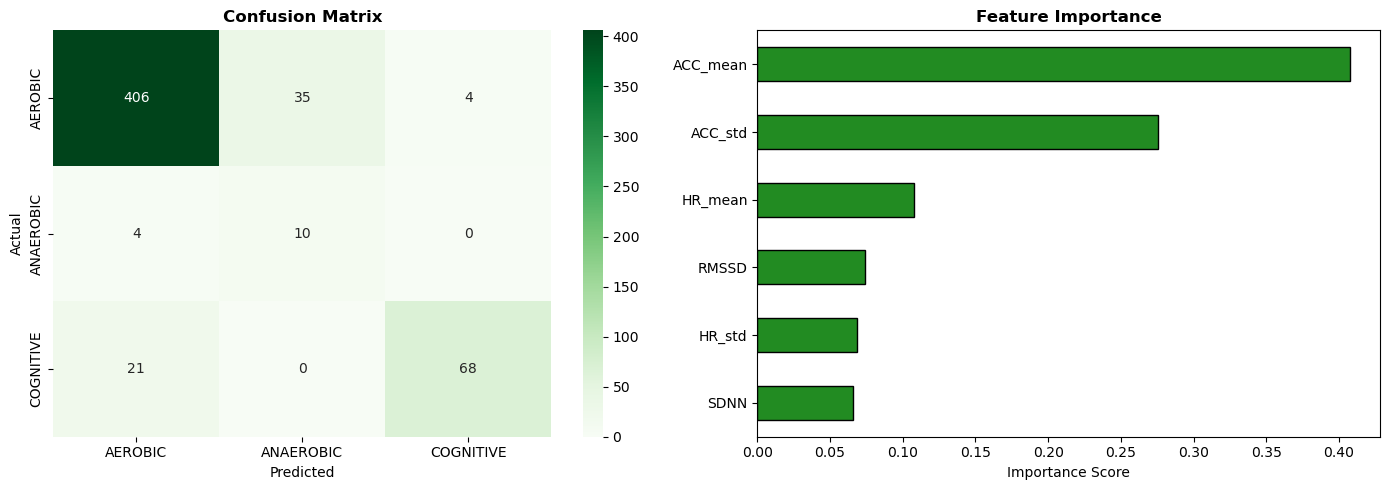


Feature Importance Ranking:
  1. ACC_mean: 0.408
  2. ACC_std: 0.276
  3. HR_mean: 0.108
  4. RMSSD: 0.074
  5. HR_std: 0.068
  6. SDNN: 0.066


In [12]:
# Apple Watch features only : Confusion Matrix and Feature Importance
# Train 
best_pipeline_apple = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42)
)

# Train/test split
# X_train_apple, X_test_apple, y_train_apple, y_test_apple = train_test_split(
#     X_apple, y_apple_encoded, test_size=0.2, random_state=42, stratify=y_apple_encoded
# )


# Subject-wise train/test split 
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx_apple, test_idx_apple = next(gss.split(X_apple, y_apple_encoded, groups=subjects))
X_train_apple, X_test_apple = X_apple.iloc[train_idx_apple], X_apple.iloc[test_idx_apple]
y_train_apple, y_test_apple = y_apple_encoded[train_idx_apple], y_apple_encoded[test_idx_apple]

best_pipeline_apple.fit(X_train_apple, y_train_apple)
y_pred_apple = best_pipeline_apple.predict(X_test_apple)

# Classification report
print("APPLE WATCH Features only MODEL - Classification Report:\n")
print(classification_report(y_test_apple, y_pred_apple, target_names=le.classes_))

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_apple = confusion_matrix(y_test_apple, y_pred_apple)
sns.heatmap(cm_apple, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Feature importance
rf_model_apple = best_pipeline_apple.named_steps['randomforestclassifier']
importances_apple = pd.Series(rf_model_apple.feature_importances_, index=apple_watch_features)
importances_apple.sort_values().plot(kind='barh', color='forestgreen', edgecolor='black', ax=axes[1])
axes[1].set_title('Feature Importance', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
for i, (feat, imp) in enumerate(importances_apple.sort_values(ascending=False).items(), 1):
    print(f"  {i}. {feat}: {imp:.3f}")

# Notes for next steps

Features on Apple watch/Health kit

- HR (continuous)
- SDNN (native HRV)
- Beat-to-beat intervals (can derive RMSSD)(ios13+)
- Steps (movement proxy)
- Resting HR

Instead of using raw ACC data we have to aggregate the steps to 30 second windows??
- steps_per_window → proxy for ACC_mean (movement intensity)
- steps_variability → proxy for ACC_std (movement regularity)